In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Top_Spotify_songs.csv')
df.head()
print(df.columns)

Index(['spotify_id', 'name', 'artists', 'daily_rank', 'daily_movement',
       'weekly_movement', 'country', 'snapshot_date', 'popularity',
       'is_explicit', 'duration_ms', 'album_name', 'album_release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature'],
      dtype='object')


In [44]:
# Average Song Attributes
avg_song = {"key": df["key"].mean(),
            "mode": df["mode"].mean(),
            "time_signature": df["time_signature"].mean(),
            "liveness": df["liveness"].mean(),
            "speechiness": df["speechiness"].mean(),
            "loudness": df["loudness"].mean(),
            "tempo": df["tempo"].mean(),
            "duration_ms": df["duration_ms"].mean(),
            "danceability": df["danceability"].mean(),
            "energy": df["energy"].mean(),
            "valence": df["valence"].mean(),
            "acousticness": df["acousticness"].mean(),
            "instrumentalness": df["instrumentalness"].mean()}

std_dev_song = {"key": df["key"].std(),
                "mode": df["mode"].std(),
                "time_signature": df["time_signature"].std(),
                "liveness": df["liveness"].std(),
                "speechiness": df["speechiness"].std(),
                "loudness": df["loudness"].std(),
                "tempo": df["tempo"].std(),
                "duration_ms": df["duration_ms"].std(),
                "danceability": df["danceability"].std(),
                "energy": df["energy"].std(),
                "valence": df["valence"].std(),
                "acousticness": df["acousticness"].std(),
                "instrumentalness": df["instrumentalness"].std()}



avg_df = pd.DataFrame({
    'Mean': avg_song,
    'Standard Deviation': std_dev_song,
    'Upper_Bin': None,
    'Lower_Bin': None
})

## https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule
for key in avg_song:
    avg_df.at[key, 'Upper_Bin'] = avg_song[key] + (1.5 * std_dev_song[key])
    avg_df.at[key, 'Lower_Bin'] = avg_song[key] - (1.5 * std_dev_song[key])
    avg_df = avg_df.round(2)
    
print(avg_df)


                       Mean  Standard Deviation    Upper_Bin      Lower_Bin
key                    5.54                3.58    10.912327       0.173675
mode                   0.54                0.50     1.285881      -0.209769
time_signature         3.90                0.40     4.508007       3.294382
liveness               0.17                0.12     0.357999      -0.016494
speechiness            0.09                0.09     0.231211      -0.041434
loudness              -6.62                3.34    -1.607598     -11.638379
tempo                122.21               28.07    164.31934      80.096663
duration_ms       193351.38            49638.48  267809.1089  118893.658489
danceability           0.68                0.14     0.890988       0.467761
energy                 0.65                0.17     0.899257       0.399269
valence                0.55                0.23     0.894039       0.205406
acousticness           0.27                0.25     0.650737       -0.10212
instrumental

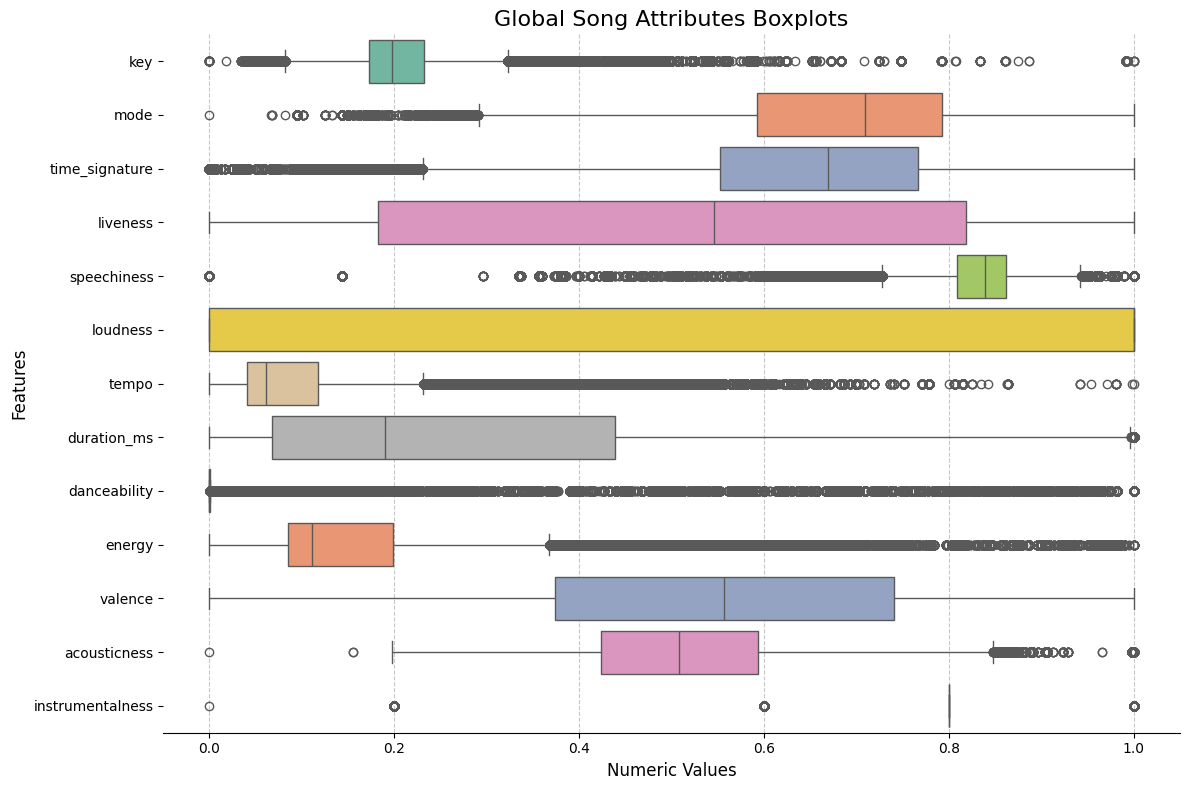

In [48]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
scaler = MinMaxScaler()

scaled = df.drop(columns=["spotify_id", "name", "artists", "daily_rank", "daily_movement", "weekly_movement", 
                              "popularity", "is_explicit", "snapshot_date", "country", "album_name", "album_release_date"], axis=1, inplace=False)

scaled = scaler.fit_transform(scaled)

scaled_df = pd.DataFrame(scaled, columns=["key", "mode", "time_signature", "liveness", "speechiness", "loudness", "tempo", "duration_ms", "danceability", "energy", "valence", "acousticness", "instrumentalness"])
# print(scaled_df)

scaled_mean = {"key": scaled_df["key"].mean(),
            "mode": scaled_df["mode"].mean(),
            "time_signature": scaled_df["time_signature"].mean(),
            "liveness": scaled_df["liveness"].mean(),
            "speechiness": scaled_df["speechiness"].mean(),
            "loudness": scaled_df["loudness"].mean(),
            "tempo": scaled_df["tempo"].mean(),
            "duration_ms": scaled_df["duration_ms"].mean(),
            "danceability": scaled_df["danceability"].mean(),
            "energy": scaled_df["energy"].mean(),
            "valence": scaled_df["valence"].mean(),
            "acousticness": scaled_df["acousticness"].mean(),
            "instrumentalness": scaled_df["instrumentalness"].mean()}

scaled_std = {"key": scaled_df["key"].std(),
                "mode": scaled_df["mode"].std(),
                "time_signature": scaled_df["time_signature"].std(),
                "liveness": scaled_df["liveness"].std(),
                "speechiness": scaled_df["speechiness"].std(),
                "loudness": scaled_df["loudness"].std(),
                "tempo": scaled_df["tempo"].std(),
                "duration_ms": scaled_df["duration_ms"].std(),
                "danceability": scaled_df["danceability"].std(),
                "energy": scaled_df["energy"].std(),
                "valence": scaled_df["valence"].std(),
                "acousticness": scaled_df["acousticness"].std(),
                "instrumentalness": scaled_df["instrumentalness"].std()}


# scaled_df = pd.DataFrame({
#     'Mean': scaled_mean,
#     'Standard Deviation': scaled_std,
#     'Upper_Bin': None,
#     'Lower_Bin': None
# })

# for key in scaled_mean:
#     scaled_df.at[key, 'Upper_Bin'] = scaled_mean[key] + (1.5 * scaled_std[key])
#     scaled_df.at[key, 'Lower_Bin'] = scaled_mean[key] - (1.5 * scaled_std[key])
#     scaled_df = avg_df.round(2)

# print(scaled_df)

plt.figure(figsize=(12, 8))  # Increase figure size for better readability
sns.boxplot(data=scaled_df, orient='h', palette='Set2')  # Horizontal boxes and a nicer palette
plt.title("Global Song Attributes Boxplots", fontsize=16)  # Larger title
plt.xlabel("Numeric Values", fontsize=12)  # Label x-axis
plt.ylabel("Features", fontsize=12)  # Label y-axis
plt.xticks(fontsize=10)  # Increase tick font size
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add a subtle grid
sns.despine(left=True) #remove the left spine.
plt.tight_layout() #prevents labels from being cut off.
plt.show()


In [ ]:
def classify_song(row):
    upper_count = 0
    lower_count = 0
    
    features = {
        'key': row['key'],
        'mode': row['mode'],
        'time_signature': row['time_signature'],
        'liveness': row['liveness'],
        'speechiness': row['speechiness'],
        'loudness': row['loudness'],
        'tempo': row['tempo'],
        'duration_ms': row['duration_ms'],
        'danceability': row['danceability'],
        'energy': row['energy'],
        'valence': row['valence'],
        'acousticness': row['acousticness'],
        'instrumentalness': row['instrumentalness']
    }

    for feat, value in features.items():
        upper_bound = avg_df.at[feat, 'Upper_Bin']
        lower_bound = avg_df.at[feat, 'Lower_Bin']
        
        if value > upper_bound:
            upper_count += 1
        elif value <= lower_bound:
            lower_count += 1

    #  logic
    total_outliers = upper_count + lower_count
    if total_outliers == 0:
        return "About_Average"
    
    # if more than 1/2 of the features higher than the average bin, than classify as higher
    # if more than 1/2 of the features lower than the average bin, than classify as lower
    outside_ratio = upper_count / total_outliers
    #print(outside_ratio)
    if outside_ratio > .5:
        #print("Higher")
        return "Higher"
    elif outside_ratio <= 0.5:
        #print("Lower")
        return "Lower"

    
df['average_song'] = df.apply(classify_song, axis=1)
print(df['average_song'].value_counts())
df['average_song'].value_counts().plot(kind='bar', title='Average Song Attribute Distribution')
plt.show()
print(df.describe())

In [ ]:
df.to_csv('dataset_with_labels.csv', index=False)
df_mod = pd.read_csv('dataset_with_labels.csv')
df_mod.head()

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,average_song
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,"Lady Gaga, Bruno Mars",1,1,0,NaN,2025-02-17,98,False,...,-7.777,0,0.0304,0.3080,0.0000,0.122,0.535,157.969,3,Lower
1,2CGNAOSuO1MEFCbBRgUzjd,luther (with sza),"Kendrick Lamar, SZA",2,1,4,NaN,2025-02-17,90,False,...,-7.546,1,0.1250,0.2510,0.0000,0.248,0.576,138.008,4,About_Average
2,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,Kendrick Lamar,3,-2,8,NaN,2025-02-17,92,True,...,-7.001,1,0.0776,0.0107,0.0000,0.141,0.214,101.061,4,Higher
3,4wJ5Qq0jBN4ajy7ouZIV1c,APT.,"ROSÉ, Bruno Mars",4,0,-2,NaN,2025-02-17,89,False,...,-4.477,0,0.2600,0.0283,0.0000,0.355,0.939,149.027,4,Higher
4,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,5,1,-2,NaN,2025-02-17,96,False,...,-10.171,1,0.0358,0.2000,0.0608,0.117,0.438,104.978,4,About_Average
